In [1]:
# This code is mainly used for case studies to 
# calculate the association scores of breast and lung neoplasms related miRNAs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import accuracy_score
import scipy as sp
from tqdm import tqdm # for progress bar

In [2]:
# reading data sets associations, mirna names and disease names respectively
m_d_associations = pd.read_csv('datasets/1.miRNA_disease_association/miRNA-disease-association-data.csv', header=None, names=["MiRNA","Disease"])
disease_names = pd.read_csv('datasets/1.miRNA_disease_association/disease name.csv', header=None)
mirna_names = pd.read_csv('datasets/1.miRNA_disease_association/miRNA name.csv', header=None)

In [3]:
m_d_associations.shape, disease_names.shape, mirna_names.shape

((5431, 2), (383, 2), (495, 2))

In [4]:
m_d_associations.head()

,MiRNA,Disease
0,0,1
1,1,1
2,2,1
3,3,1
4,4,2


In [5]:
# importing adjacency matrix and integrated mirna and disease features

# A = Adjacency matrix, SM = integrated mirna features, SD = integrated disease features

nm = len(mirna_names)
nd = len(disease_names)
A = np.loadtxt("datasets/adjacency_matrix.txt")
SM = np.loadtxt("datasets/mirna_integrated_similarity.txt")
SD = np.loadtxt("datasets/disease_integrated_similarity.txt")

In [6]:
# creating dataframes from matrices
A_df = pd.DataFrame(A, index=range(1, nm+1), columns=range(1, nd+1))
SM_df = pd.DataFrame(SM, index=range(1, nm+1), columns=range(1, nm+1))
SD_df = pd.DataFrame(SD, index=range(1, nd+1), columns=range(1, nd+1))

In [7]:
A.shape, SM.shape, SD.shape

((495, 383), (495, 495), (383, 383))

In [8]:
# previewing adjacency matrix
A_df

,1,2,3,4,5,6,7,8,9,10,...,374,375,376,377,378,379,380,381,382,383
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
493,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


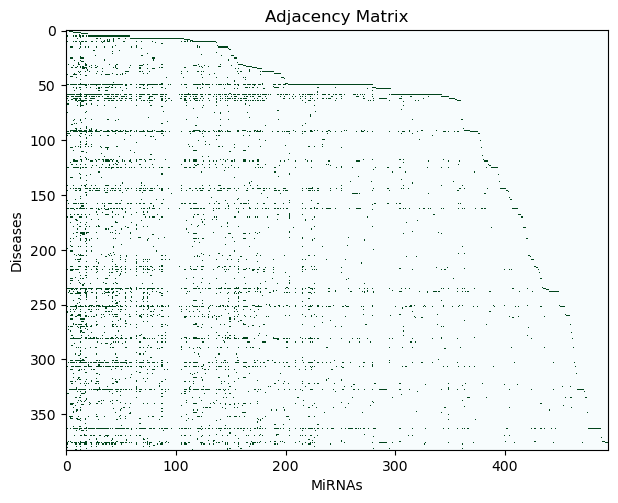

In [9]:
# plotting adjacency matrix
fig = plt.figure(figsize=(7, 10)) # in inches
plt.title('Adjacency Matrix')
plt.xlabel('MiRNAs')
plt.ylabel('Diseases')
plt.imshow(A_df.T, cmap="BuGn", interpolation="none")

In [10]:
SM_df

,1,2,3,4,5,6,7,8,9,10,...,486,487,488,489,490,491,492,493,494,495
1,1.000000,0.476800,0.093465,0.353500,0.544400,0.482700,0.490000,0.496600,0.476600,0.639200,...,0.093465,0.093465,0.093465,0.077888,0.077888,0.077888,0.077888,0.077888,0.077888,0.077888
2,0.476800,1.000000,0.077888,0.289800,0.402700,0.474700,0.524900,0.326500,0.487100,0.422700,...,0.064907,0.064907,0.064907,0.054089,0.054089,0.054089,0.064907,0.064907,0.064907,0.064907
3,0.093465,0.077888,1.000000,0.147435,0.008736,0.009570,0.015095,0.037562,0.012579,0.006067,...,0.161507,0.161507,0.161507,0.161507,0.193809,0.193809,0.161507,0.161507,0.161507,0.161507
4,0.353500,0.289800,0.147435,1.000000,0.420600,0.417500,0.309400,0.192000,0.221200,0.315800,...,0.440237,0.440237,0.440237,0.440237,0.440237,0.440237,0.440237,0.440237,0.440237,0.440237
5,0.544400,0.402700,0.008736,0.420600,1.000000,0.805400,0.541500,0.438800,0.278600,0.445200,...,0.012579,0.012579,0.012579,0.010483,0.012579,0.012579,0.010483,0.010483,0.010483,0.010483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,0.077888,0.054089,0.193809,0.440237,0.012579,0.013780,0.015095,0.064907,0.018114,0.005055,...,0.833334,0.833334,0.833334,0.833334,1.000000,1.000000,0.833334,0.833334,0.833334,0.833334
492,0.077888,0.064907,0.161507,0.440237,0.010483,0.016536,0.015095,0.077888,0.021737,0.006067,...,0.833334,0.833334,0.833334,0.833334,0.833334,0.833334,1.000000,1.000000,1.000000,0.833334
493,0.077888,0.064907,0.161507,0.440237,0.010483,0.016536,0.015095,0.077888,0.021737,0.006067,...,0.833334,0.833334,0.833334,0.833334,0.833334,0.833334,1.000000,1.000000,1.000000,0.833334
494,0.077888,0.064907,0.161507,0.440237,0.010483,0.016536,0.015095,0.077888,0.021737,0.006067,...,0.833334,0.833334,0.833334,0.833334,0.833334,0.833334,1.000000,1.000000,1.000000,0.833334


In [11]:
SD_df

,1,2,3,4,5,6,7,8,9,10,...,374,375,376,377,378,379,380,381,382,383
1,1.000000,0.038240,0.460301,0.530038,0.754171,0.036330,0.754171,0.013534,0.460301,0.460301,...,0.460301,0.493940,0.159791,0.059719,0.049938,0.702809,0.399739,0.868430,0.493940,0.568774
2,0.038240,1.000000,0.460301,0.530038,0.754171,0.031550,0.754171,0.084313,0.460301,0.460301,...,0.460301,0.493940,0.073187,0.097589,0.121246,0.702809,0.399739,0.754171,0.034299,0.568774
3,0.460301,0.460301,1.000000,0.015619,0.610340,0.152393,0.244850,0.010953,0.188205,0.164830,...,0.323504,0.347146,0.112303,0.066923,0.056765,0.493940,0.372515,0.530038,0.059536,0.610340
4,0.530038,0.530038,0.015619,1.000000,0.610340,0.033856,0.610340,0.010953,0.372515,0.372515,...,0.372515,0.399739,0.148909,0.002015,0.033856,0.568774,0.164015,0.610340,0.098012,0.460301
5,0.754171,0.754171,0.610340,0.610340,1.000000,0.041835,0.868430,0.015584,0.530038,0.530038,...,0.530038,0.568774,0.188323,0.001416,0.036330,0.809287,0.460301,0.868430,0.568774,0.092230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,0.702809,0.702809,0.493940,0.568774,0.809287,0.033856,0.809287,0.019256,0.493940,0.493940,...,0.493940,0.530038,0.148909,0.001320,0.029402,1.000000,0.428953,0.809287,0.530038,0.610340
380,0.399739,0.399739,0.372515,0.164015,0.460301,0.038985,0.530038,0.012612,0.280940,0.280940,...,0.428953,0.301472,0.097527,0.002672,0.044892,0.428953,1.000000,0.460301,0.119578,0.460301
381,0.868430,0.754171,0.530038,0.610340,0.868430,0.041835,0.868430,0.015584,0.530038,0.530038,...,0.530038,0.568774,0.159791,0.001631,0.036330,0.809287,0.460301,1.000000,0.568774,0.654945
382,0.493940,0.034299,0.059536,0.098012,0.568774,0.090869,0.106929,0.010207,0.029568,0.026842,...,0.347146,0.372515,0.120510,0.028992,0.025345,0.530038,0.119578,0.568774,1.000000,0.493940


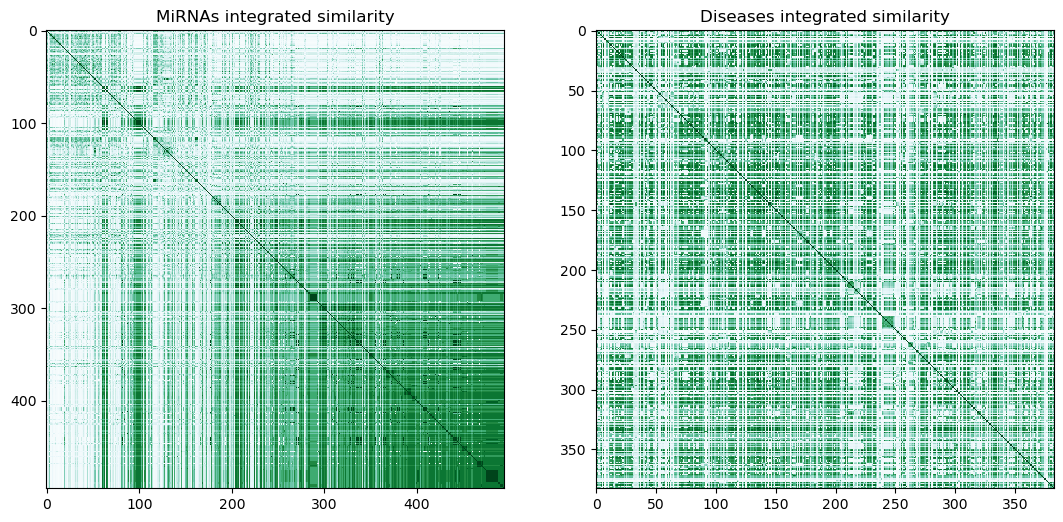

In [12]:
# integrated mirna and disease similarities

fig, (fig1, fig2) = plt.subplots(1, 2, figsize=(13,13))
fig1.title.set_text('MiRNAs integrated similarity')
fig2.title.set_text('Diseases integrated similarity')
fig1.imshow(SM, cmap="BuGn", interpolation="none")
fig2.imshow(SD, cmap="BuGn", interpolation="none")

## Computing similarity information

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import random

In [14]:
# calculating cosine similarities for collaborative filtering
mirna_similarity_cosine = cosine_similarity(SM)
disease_similarity_cosine = cosine_similarity(SD)

In [15]:
type(mirna_similarity_cosine), type(disease_similarity_cosine)

(numpy.ndarray, numpy.ndarray)

In [16]:
# mirna similarity matrix using cosine similarity
print(mirna_similarity_cosine)
np.savetxt("datasets/mirna_similarity_cosine_matrix.txt", mirna_similarity_cosine)

[[1.         0.93806281 0.49286203 ... 0.40172316 0.40172316 0.4024244 ]
 [0.93806281 1.         0.48348297 ... 0.38458609 0.38458609 0.38549736]
 [0.49286203 0.48348297 1.         ... 0.92591413 0.92591413 0.92743335]
 ...
 [0.40172316 0.38458609 0.92591413 ... 1.         1.         0.99873738]
 [0.40172316 0.38458609 0.92591413 ... 1.         1.         0.99873738]
 [0.4024244  0.38549736 0.92743335 ... 0.99873738 0.99873738 1.        ]]


In [17]:
# diseases similarity matrix using cosine similarity
print(disease_similarity_cosine)
np.savetxt("datasets/disease_similarity_cosine_matrix.txt", disease_similarity_cosine)

[[1.         0.91976595 0.79240978 ... 0.92777234 0.79957548 0.95039413]
 [0.91976595 1.         0.77912727 ... 0.88035735 0.74311498 0.89977992]
 [0.79240978 0.77912727 1.         ... 0.79975302 0.779439   0.82489632]
 ...
 [0.92777234 0.88035735 0.79975302 ... 1.         0.80414326 0.95386929]
 [0.79957548 0.74311498 0.779439   ... 0.80414326 1.         0.79288968]
 [0.95039413 0.89977992 0.82489632 ... 0.95386929 0.79288968 1.        ]]


In [18]:
# getting most similar items using cosine similarity

SIMILARITY_THRESHOLD = 0.05
N_SIMILAR = 30
def cosineSimilarity(cos_sim_matrix):
    similar_items = []
    for current_item in cos_sim_matrix.index:
        # excluding the current item without modifying the original matrix
        candidates = cos_sim_matrix.drop(index=current_item)
        similar_i = (
            candidates.loc[candidates[current_item] > SIMILARITY_THRESHOLD, current_item]
            .sort_values(ascending=False)
            .head(N_SIMILAR)
        )
        similar_items.append(similar_i)

    return similar_items

In [19]:
# getting most similar mirnas and diseases
similar_mirnas = cosineSimilarity(pd.DataFrame(mirna_similarity_cosine, index=range(1, nm+1), columns=range(1, nm+1)))
similar_diseases = cosineSimilarity(pd.DataFrame(disease_similarity_cosine, index=range(1, nd+1), columns=range(1, nd+1)))
type(similar_mirnas), type(similar_diseases)

(list, list)

In [20]:
# similar_mirnas, similar_diseases

In [21]:
# getting index of similar items for mirna 1, and the length of similar mirnas
# similar_mirnas[0].index, len(similar_mirnas)

## Model case study evaluation using known mirna-disease associations

In [22]:
# calculating association scores of known associations for miRNAs related to breast and lung neoplasms
case_study_df = m_d_associations[(m_d_associations['Disease']==50) | (m_d_associations['Disease']==236)]
case_study_df

,MiRNA,Disease
457,7,50
458,117,50
459,118,50
460,119,50
461,59,50
...,...,...
3132,55,236
3133,56,236
3134,57,236
3135,280,236


### Case study evaluation class

In [23]:
# Case study evaluation class
class Case_study_association_evaluation:
    def __init__(self, SMdf, SDdf, Adj):
        self.SMdf = SMdf
        self.SDdf = SDdf
        self.A = Adj.to_numpy()

    #calculating association score a given pair
    def calcScore(self, mirna, disease):
        # top n similar miRNAs and diseases already generated above
        mirna_neighbors = similar_mirnas[mirna]
        disease_neighbors = similar_diseases[disease]
        
        if len(mirna_neighbors) == 0 or len(disease_neighbors) == 0:
            return [mirna, disease, 0.0]

        #gettign the neighbor IDs
        mirna_ids = mirna_neighbors.index.to_numpy(dtype=int)
        disease_ids = disease_neighbors.index.to_numpy(dtype=int)

        # similarity values
        mirna_sim = mirna_neighbors.to_numpy(dtype=float)
        disease_sim = disease_neighbors.to_numpy(dtype=float)
        A_block = self.A[np.ix_(mirna_ids - 1, disease_ids - 1)]

        # CF score: sum(sim_miRNA * sim_disease * association)
        weighted = (mirna_sim[:, None] * disease_sim[None, :] * A_block)
        score = weighted.sum()

        return [mirna, disease, float(score)]

    # Getting score predictions for case-study pairs
    def eval_score_predictions(self, df):
        eval_associations = []
        seen_pairs = set()
        for _, r in tqdm(df.iterrows(), total=len(df)):
            mirna = int(r["MiRNA"])
            disease = int(r["Disease"])
            pair = (mirna, disease)
            if pair in seen_pairs:
                continue

            seen_pairs.add(pair)
            prediction = self.calcScore(mirna, disease)
            eval_associations.append(prediction)

        print("Case study execution completed!")

        return eval_associations

In [24]:
# Evaluation class object
eval_pred = Case_study_association_evaluation(SM_df, SD_df, A_df)
evaluation_scores = eval_pred.eval_score_predictions(case_study_df)
evaluation_scores

100%|██████████| 334/334 [00:00<00:00, 12661.76it/s]

Case study execution completed!


[[7, 50, 57.850147754577236],
 [117, 50, 70.15434653581468],
 [118, 50, 68.55229310807452],
 [119, 50, 46.32997368667479],
 [59, 50, 35.95988652649403],
 [162, 50, 74.67481767796235],
 [163, 50, 78.46055709732242],
 [164, 50, 0.8638644101870029],
 [109, 50, 39.973208860488675],
 [60, 50, 0.9367983201147992],
 [21, 50, 20.846253886172793],
 [203, 50, 10.879469343652426],
 [120, 50, 18.42291012520497],
 [140, 50, 13.288232753269483],
 [171, 50, 15.75424285193171],
 [23, 50, 84.09904467718201],
 [15, 50, 32.06047903990381],
 [204, 50, 0.9356637505821445],
 [141, 50, 1.8178145021604377],
 [205, 50, 0.9356637505821445],
 [206, 50, 0.0],
 [207, 50, 0.0],
 [1, 50, 26.83431323333047],
 [65, 50, 0.9367983201147992],
 [24, 50, 5.941303047094151],
 [172, 50, 6.728630819438804],
 [142, 50, 0.795275342183432],
 [208, 50, 0.9356637505821445],
 [180, 50, 1.6991351421512229],
 [121, 50, 5.479186329421058],
 [209, 50, 7.6076105079646705],
 [16, 50, 12.990680898415956],
 [17, 50, 85.36896770009182],
 [2

In [ ]:
#creating an evaluation scores df
evaluation_scores_df = pd.DataFrame(evaluation_scores, columns=["MiRNA", "Disease", "Score"])
evaluation_scores_df.to_csv("datasets/predicted_associations/case_study/evaluation_breast_lung_knownpred_scores_jan9_2.csv", index=False)

In [26]:
evaluation_scores_df = evaluation_scores_df.head(50)

In [27]:
total_pairs = 0
for i in evaluation_scores_df['Score']:
    if i > 0.01:
        total_pairs += 1

print(total_pairs)

46
